# A/B testing en un marketplace — ¿un rediseño de la ficha de producto aumenta el AOV?

**Proyecto de portfolio · metodología CRISP-DM · dataset Brazilian E-Commerce by Olist**

Este notebook es la capa narrativa reproducible del proyecto. Todo el cálculo vive en `src/`;
aquí se ejecuta el pipeline de punta a punta y se cuenta la historia. Cada sección está
etiquetada con su fase de CRISP-DM.

> **Nota de honestidad metodológica.** El dataset de Olist no trae grupos control/tratamiento.
> La asignación se **simula** y el efecto del tratamiento se **inyecta de forma declarada**
> (modelo diluido: 20 % de los tratados responde con +25 %, efecto medio +5 %). El objetivo del
> proyecto **no** es descubrir si el rediseño funciona —lo sabemos, porque el efecto lo ponemos
> nosotros—, sino **demostrar que el diseño y el análisis estadístico controlan los falsos
> positivos y recuperan sin sesgo un efecto de tamaño conocido**. Es la competencia que se
> evalúa en un rol de experimentación de producto.

In [1]:
import os
import sys
import json
from pathlib import Path

# situarse en la raíz del repo (el notebook vive en notebooks/)
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
RNG_SEED = 42


def _l(x):
    """lista de floats nativos (evita el ruido de np.float64(...) al imprimir)."""
    return [round(float(v), 3) for v in x]


print("cwd:", Path.cwd())

cwd: C:\Users\pardo\Proyecto AB testing


---
## Fase 1 — Comprensión del negocio (Business Understanding)

**Contexto.** Olist es un marketplace que conecta a pequeños vendedores brasileños con los
grandes canales de venta online. El equipo de Producto propone un **rediseño de la ficha de
producto** (recomendaciones de *cross-sell* + barra de progreso hacia envío gratuito) con la
hipótesis de que **aumenta el valor medio del pedido (AOV)** sin dañar la satisfacción ni las
cancelaciones.

**Limitación estructural (decisión de alcance).** El dataset arranca en el pedido: no hay
sesiones ni carritos → **no se puede medir conversión**. La métrica primaria es el **AOV**.

| Elemento | Definición |
|---|---|
| **H0** | μ_treatment − μ_control = 0 (el rediseño no cambia el AOV) |
| **H1** | μ_treatment − μ_control ≠ 0 (bilateral, α = 0,05) |
| **Métrica primaria** | AOV = Σ `order_items.price` por pedido (valor de mercancía) |
| **Guardrails** | G1 review_score · G2 tasa de cancelación · G3 flete · G4 nº de ítems (corrección Benjamini-Hochberg) |
| **MDE de relevancia** | **+3 %** relativo sobre el AOV base |
| **Regla de decisión** | LANZAR si p < 0,05 **y** IC 95 % del lift enteramente por encima de +3 % **y** ningún guardrail degradado; ITERAR si significativo pero IC toca el MDE; NO LANZAR en otro caso |

Detalle completo: `docs/01_business_understanding.md`.

In [2]:
from modeling import SEED, ALPHA, P_RESP, DELTA_RESP, ATE, MDE_RELEVANCIA

print("Parámetros declarados del experimento simulado")
print(f"  semilla                : {SEED}")
print(f"  alpha (bilateral)      : {ALPHA}")
print(f"  efecto diluido         : {P_RESP:.0%} responde con +{DELTA_RESP:.0%}  ->  ATE = +{ATE:.0%}")
print(f"  MDE de relevancia      : +{MDE_RELEVANCIA:.0f}%")

Parámetros declarados del experimento simulado
  semilla                : 42
  alpha (bilateral)      : 0.05
  efecto diluido         : 20% responde con +25%  ->  ATE = +5%
  MDE de relevancia      : +3%


---
## Fase 2 — Comprensión de los datos (Data Understanding)

Dataset: [Brazilian E-Commerce by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
· licencia **CC BY-NC-SA 4.0** (verificada en la descarga) · ~100 k pedidos · 9 tablas relacionales
· periodo útil **2017-01 → 2018-08**.

In [3]:
from profiling_fase2 import load, describe_series

orders, items, payments, reviews, customers, products = load()
merch = items.groupby("order_id")["price"].sum()
valid = {"delivered", "shipped", "invoiced", "approved", "processing"}
oid_valid = orders.loc[orders.order_status.isin(valid), "order_id"]
aov = merch.reindex(oid_valid).dropna()

stats_tbl = pd.DataFrame({
    "AOV (merch_value)": describe_series(aov),
    "log(AOV)": describe_series(np.log(aov.clip(lower=0.01))),
}).T[["n", "mean", "median", "std", "cv", "skew", "kurtosis_excess", "p95", "p99", "max"]]
display(stats_tbl.round(3))

_cu = (orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
       .loc[lambda d: d.order_id.isin(set(oid_valid)), "customer_unique_id"].nunique())
print(f"\nClientes únicos con pedido válido: {_cu:,}")
print("Lectura: AOV muy asimétrico (skew ~9,8); log(AOV) casi simétrico (skew ~0,24).")
print("A n grande, la media es normal por el TCL -> Welch-t es el test primario.")

,n,mean,median,std,cv,skew,kurtosis_excess,p95,p99,max
AOV (merch_value),98199.0,137.419,86.900,209.306,1.523,9.772,271.395,399.800,995.020,13440.000
log(AOV),98199.0,4.443,4.465,0.932,0.210,0.242,0.335,5.991,6.903,9.506



Clientes únicos con pedido válido: 94,986
Lectura: AOV muy asimétrico (skew ~9,8); log(AOV) casi simétrico (skew ~0,24).
A n grande, la media es normal por el TCL -> Welch-t es el test primario.


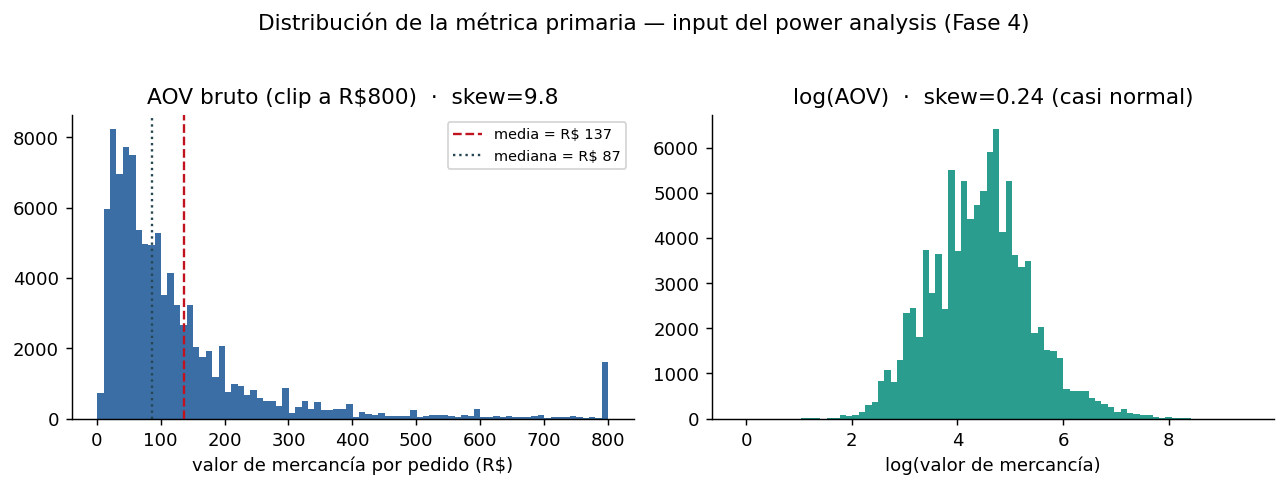

In [4]:
display(Image("outputs/figures/f2_02_distribucion_aov.png"))

**Limitaciones de validez** (detalle en `docs/02_data_understanding.md` §2.7): sin aleatorización
real ni capa de tráfico; efecto inyectado de forma declarada; ventana histórica de 2 años (no un
experimento de 2–4 semanas); recompra ~3 % → sin métrica de retención; mercado único.

---
## Fase 3 — Preparación de los datos (Data Preparation)

Limpieza dirigida a la pregunta experimental. Cada paso queda trazado.

In [5]:
from prepare_data import build_order_table, dedup_one_order_per_customer, add_winsor_and_assignment

tab = build_order_table()
tab = dedup_one_order_per_customer(tab)
tab = add_winsor_and_assignment(tab)
tab.to_parquet("data/processed/analytical_table.parquet", index=False)

display(pd.read_csv("outputs/tables/fase3_transformaciones.csv"))


=== Construcción de la tabla de pedidos (crudo: 99441 pedidos) ===
[ventana_temporal] 99441 -> 99092 (-349)  · restringir a [2017-01-01, 2018-09-01) por realismo (no corrige sesgo, §B6)
[estados_validos] 99092 -> 97905 (-1187)  · conservar ['approved', 'delivered', 'invoiced', 'processing', 'shipped'] = compra realizada; excluir canceled/unavailable/created


[pedidos_con_items] 97905 -> 97905 (+0)  · excluir pedidos sin líneas en order_items (no tienen métrica primaria)


[dedup_1_pedido_cliente] 97905 -> 94703 (-3202)  · quedarse con el primer pedido de cada cliente -> unidad aleatorización = unidad análisis (§B3)
[winsor] cap p99.5 = R$ 1,360.00  ·  473 pedidos recortados (0.50%)  ·  col `merch_value_w` (solo para el contraste)
[asignación] semilla=42  ·  control=47280  treatment=47423  (50.08% treatment)


,paso,n_antes,n_despues,delta,justificacion
0,ventana_temporal,99441,99092,-349,"restringir a [2017-01-01, 2018-09-01) por real..."
1,estados_validos,99092,97905,-1187,"conservar ['approved', 'delivered', 'invoiced'..."
2,pedidos_con_items,97905,97905,0,excluir pedidos sin líneas en order_items (no ...
3,dedup_1_pedido_cliente,97905,94703,-3202,quedarse con el primer pedido de cada cliente ...


**Decisiones de preparación** (auditoría en `docs/auditoria_fase1_fase2.md`):
ventana 2017-01/2018-08 · dedup de reseñas por `review_answer_timestamp` · **dedup a 1
pedido/cliente** (unidad de aleatorización = unidad de análisis; mueve el AOV solo −0,35 %) ·
**winsorización p99,5 solo para el contraste** (columna `merch_value_w`; el AOV descriptivo va sin
winsorizar).

,covariable,tipo,|SMD|,p_omnibus
0,n_items,continua,-0.0036,0.579
1,freight_value,continua,0.0067,0.305
2,customer_state,categórica (27),0.0127,0.918
3,cat_dominante,categórica (72),0.0200,0.320
4,payment_type,categórica (4),0.0085,0.623
5,mes_compra,categórica (20),0.0153,0.693


Todas |SMD| < 0,10: True   ·   ningún ómnibus significativo: True


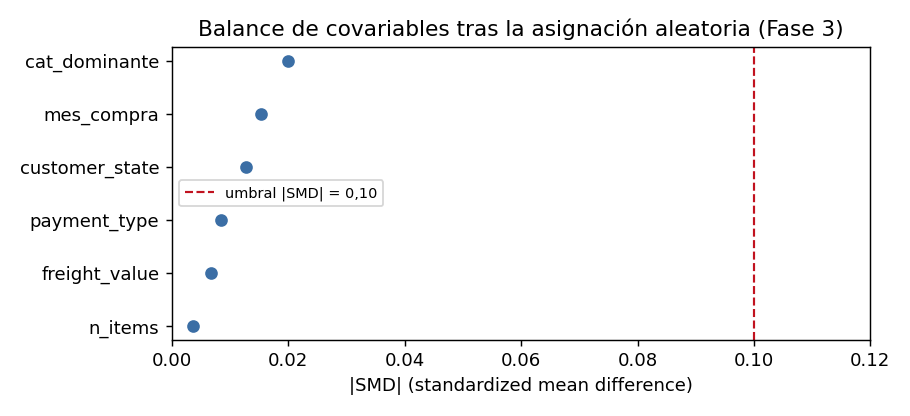

In [6]:
# --- Covariate balance check sobre la asignación simulada ---
from balance_check import smd_continuous, smd_binary
import scipy.stats as st

df = pd.read_parquet("data/processed/analytical_table.parquet")
c, t = df[df.group == "control"], df[df.group == "treatment"]
rows = []
for col in ["n_items", "freight_value"]:
    rows.append([col, "continua", round(smd_continuous(t[col], c[col]), 4),
                 round(st.ttest_ind(t[col], c[col], equal_var=False)[1], 3)])
for col in ["customer_state", "cat_dominante", "payment_type", "mes_compra"]:
    ct = pd.crosstab(df[col], df.group)
    chi2, p, *_ = st.chi2_contingency(ct)
    pc, ptt = c[col].value_counts(normalize=True), t[col].value_counts(normalize=True)
    smd = max(abs(smd_binary(ptt.get(l, 0), pc.get(l, 0))) for l in pc.index.union(ptt.index))
    rows.append([col, f"categórica ({ct.shape[0]})", round(smd, 4), round(p, 3)])
bal = pd.DataFrame(rows, columns=["covariable", "tipo", "|SMD|", "p_omnibus"])
display(bal)
print(f"Todas |SMD| < 0,10: {(bal['|SMD|'] < 0.10).all()}   ·   ningún ómnibus significativo: "
      f"{(bal.p_omnibus >= 0.05).all()}")
display(Image("outputs/figures/f3_01_balance.png"))

---
## Fase 4 — Modeling (diseño estadístico del experimento)

Power analysis a priori → verificación de supuestos → calibración A/A (2.000 particiones) →
test A/B con el efecto declarado. **Puede tardar ~1 min** (simulaciones con semilla fija).

POWER ANALYSIS
  [crudo       ] MDE detectable 80% = +2.789%  ·  potencia(ATE=+5%, diluido) = 1.0  ·  lift medio estimado (1000 sims) = 4.999%  (sesgo ≈ 0)
  [winsor_p99.5] MDE detectable 80% = +2.336%  ·  potencia(ATE=+5%, diluido) = 1.0  ·  lift medio estimado (1000 sims) = 5.006%  (sesgo ≈ 0)

  Penalización de potencia por efecto diluido: -0.11 pp  ->  despreciable (la varianza natural del AOV, CV≈1,5, domina). Predicción de la Fase 1 cuantificada.


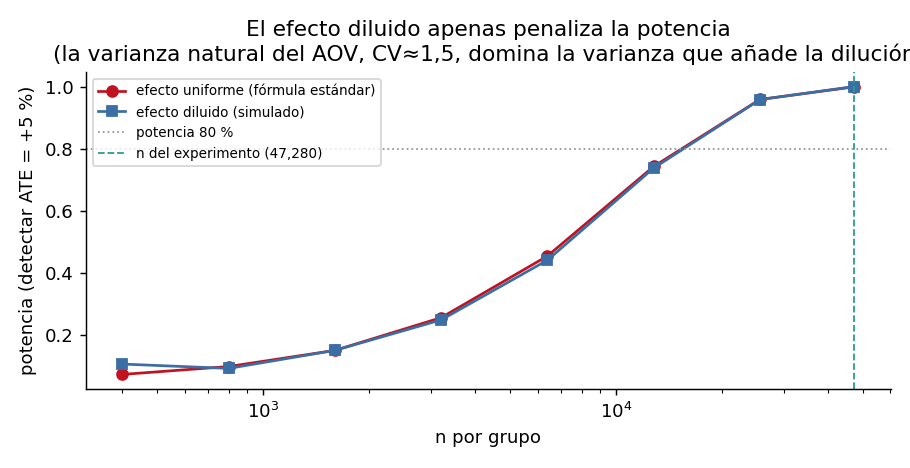

In [7]:
from modeling import power_analysis, check_assumptions, aa_calibration, run_ab_test

pw = power_analysis(df)
print("POWER ANALYSIS")
for k in ["crudo", "winsor_p99.5"]:
    r = pw[k]
    print(f"  [{k:12}] MDE detectable 80% = +{r['mde_rel_detectable_80pct_pct']}%  ·  "
          f"potencia(ATE=+5%, diluido) = {r['power_efecto_diluido_+5pct_ATE']}  ·  "
          f"lift medio estimado (1000 sims) = {r['lift_medio_estimado_sim_pct']}%  (sesgo ≈ 0)")
pen = pw["crudo"]["penalizacion_potencia_por_dilucion_pp"]
print(f"\n  Penalización de potencia por efecto diluido: {pen} pp  ->  despreciable "
      f"(la varianza natural del AOV, CV≈1,5, domina). Predicción de la Fase 1 cuantificada.")
display(Image("outputs/figures/f4_04_power_vs_n.png"))

VERIFICACIÓN DE SUPUESTOS
  Normalidad de los datos brutos : p = 0.0  (no normal, esperado)
  Normalidad de la media (TCL)   : p = 0.8259  -> Welch-t válido
  Homocedasticidad SIN efecto    : Levene p = 0.2048
  Homocedasticidad CON efecto    : Levene p = 1.64e-06  -> varianzas desiguales bajo H1  ->  usar Welch, NO Student


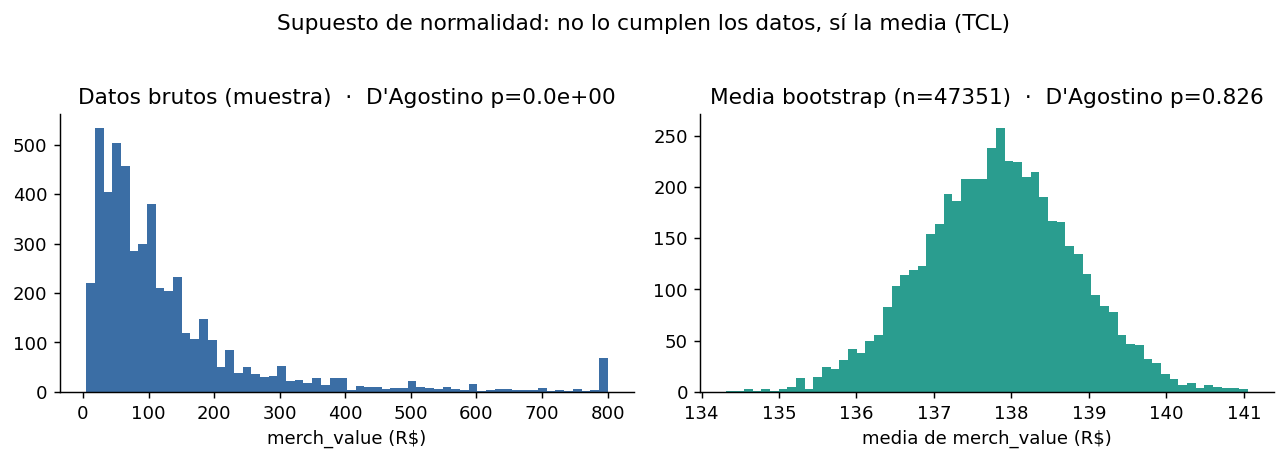

In [8]:
asm = check_assumptions(df)
print("VERIFICACIÓN DE SUPUESTOS")
print(f"  Normalidad de los datos brutos : p = {asm['normalidad_datos_brutos']['p']}  (no normal, esperado)")
print(f"  Normalidad de la media (TCL)   : p = {asm['normalidad_de_la_media_bootstrap']['p']}  -> Welch-t válido")
print(f"  Homocedasticidad SIN efecto    : Levene p = {asm['homocedasticidad_sin_efecto']['p']}")
print(f"  Homocedasticidad CON efecto    : Levene p = {asm['homocedasticidad_con_efecto_diluido']['p']}"
      f"  -> varianzas desiguales bajo H1  ->  usar Welch, NO Student")
display(Image("outputs/figures/f4_01_tcl_normalidad.png"))

CALIBRACIÓN A/A  (2.000 particiones aleatorias, sin efecto)
  [merch_value   ] falsos positivos = 0.050  (IC95 [0.04, 0.059])  ·  KS p-valores = 0.527  ->  calibrado
  [merch_value_w ] falsos positivos = 0.050  (IC95 [0.04, 0.06])  ·  KS p-valores = 0.933  ->  calibrado
  [log_merch     ] falsos positivos = 0.050  (IC95 [0.04, 0.06])  ·  KS p-valores = 0.725  ->  calibrado


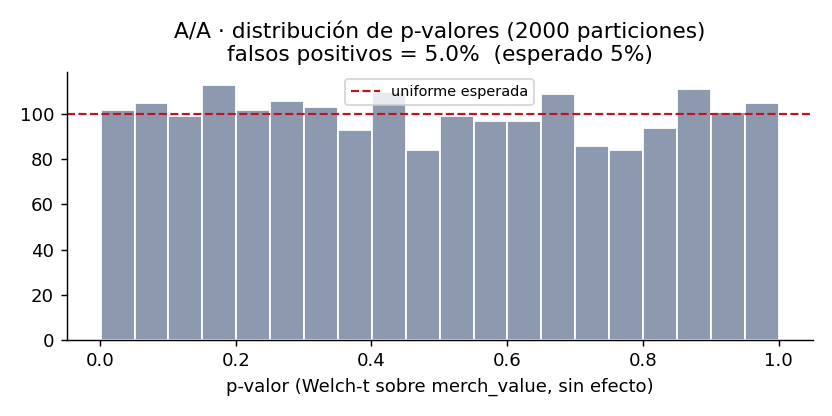

In [9]:
aa = aa_calibration(df)
print("CALIBRACIÓN A/A  (2.000 particiones aleatorias, sin efecto)")
for k, v in aa.items():
    print(f"  [{k:14}] falsos positivos = {v['tasa_falsos_positivos_alpha_0.05']:.3f}  "
          f"(IC95 {_l(v['IC95_tasa'])})  ·  KS p-valores = {v['KS_vs_uniforme_p']:.3f}  ->  {v['veredicto']}")
display(Image("outputs/figures/f4_02_aa_pvalores.png"))

TEST A/B  —  efecto diluido inyectado (SEED=42)
  PRIMARIO  Welch · AOV winsor : lift = +5.666%  IC95 [3.994, 7.337]%  ·  p = 3.095e-11
  robustez  Welch crudo       : +6.111%  [4.091, 8.131]%
  robustez  bootstrap (10k)   : [4.048, 8.187]%
  el efecto verdadero (+5 %) está dentro del IC: True

  GUARDRAILS (Benjamini-Hochberg):
    G1_review_score       p ajustado BH = 0.804  ->  degradado: False
    G2_cancelacion        p ajustado BH = 0.772  ->  degradado: False
    G3_freight_value      p ajustado BH = 0.772  ->  degradado: False
    G4_n_items            p ajustado BH = 0.772  ->  degradado: False


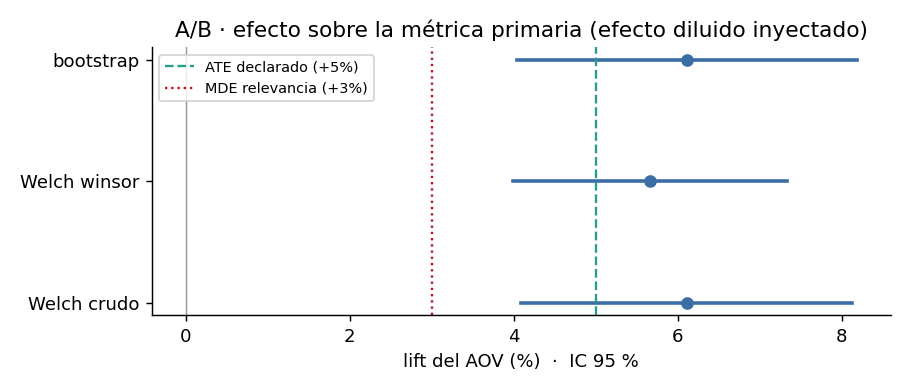

In [10]:
ab = run_ab_test(df)
p = ab["primario"]
print("TEST A/B  —  efecto diluido inyectado (SEED=42)")
print(f"  PRIMARIO  Welch · AOV winsor : lift = +{p['Welch_winsor_p99.5']['lift_rel_pct']}%  "
      f"IC95 {_l(p['Welch_winsor_p99.5']['IC95_lift_pct'])}%  ·  p = {p['Welch_winsor_p99.5']['p_value']}")
print(f"  robustez  Welch crudo       : +{p['Welch_crudo']['lift_rel_pct']}%  {_l(p['Welch_crudo']['IC95_lift_pct'])}%")
print(f"  robustez  bootstrap (10k)   : {_l(p['bootstrap_ratio']['IC95_lift_pct'])}%")
print(f"  el efecto verdadero (+5 %) está dentro del IC: {p['Welch_winsor_p99.5']['ATE_5pct_en_IC']}")
print("\n  GUARDRAILS (Benjamini-Hochberg):")
for g, v in ab["guardrails"].items():
    print(f"    {g:20}  p ajustado BH = {v['p_ajustado_BH']:.3f}  ->  degradado: {v['significativo_tras_BH']}")
display(Image("outputs/figures/f4_03_ab_efecto.png"))

---
## Fase 5 — Evaluación (Evaluation)

In [11]:
import contextlib
import io
import evaluation

with contextlib.redirect_stdout(io.StringIO()):   # evaluation.main() imprime el JSON completo
    evaluation.main()
print("Fase 5 ejecutada -> outputs/tables/fase5_resumen.json")

Fase 5 ejecutada -> outputs/tables/fase5_resumen.json


In [12]:
res5 = json.load(open("outputs/tables/fase5_resumen.json"))
prim = res5["1_resultado_primario"]
imp = res5["2_impacto_negocio"]
anc = res5["3_ancova"]

print("SIGNIFICANCIA vs RELEVANCIA")
print(f"  Efecto primario : +{prim['lift_pct']}%   IC95 {_l(prim['IC95_lift_pct'])}%   log10(p) = {prim['log10_p']}")
print(f"  ¿significativo?  : {prim['significativo']}")
print(f"  ¿IC entero sobre el MDE +3 %?  : {prim['ci_entero_sobre_MDE']}   ->  RELEVANTE: {prim['relevante']}")
print(f"\n  ANCOVA (ajuste por covariables): +{anc['con_ajuste']['lift_pct']}%  "
      f"IC95 {_l(anc['con_ajuste']['ci95_pct'])}%  ·  SE −{anc['reduccion_SE_pct']}%")
print(f"\nIMPACTO ECONÓMICO ESTIMADO")
print(f"  Uplift de GMV de mercancía : +R$ {imp['uplift_GMV_anual_R$']:,}/año  "
      f"(IC [{imp['uplift_GMV_anual_IC95_R$'][0]:,}, {imp['uplift_GMV_anual_IC95_R$'][1]:,}])")
print(f"  ≈ +R$ {imp['uplift_ingreso_marketplace_anual_R$_asumiendo_comision_15pct']:,}/año de comisión (15 %)")

SIGNIFICANCIA vs RELEVANCIA
  Efecto primario : +5.666%   IC95 [3.994, 7.337]%   log10(p) = -10.51
  ¿significativo?  : True
  ¿IC entero sobre el MDE +3 %?  : True   ->  RELEVANTE: True

  ANCOVA (ajuste por covariables): +5.193%  IC95 [3.709, 6.677]%  ·  SE −11.23%

IMPACTO ECONÓMICO ESTIMADO
  Uplift de GMV de mercancía : +R$ 456,084/año  (IC [321,514, 590,655])
  ≈ +R$ 68,413/año de comisión (15 %)


SEGMENTOS PRE-ESPECIFICADOS  —  test de interacción (log(AOV), Wald HC3, + Benjamini-Hochberg)
  cesta           p bruto = 0.924   p BH = 0.924   heterogéneo: False
  payment_type    p bruto = 0.377   p BH = 0.924   heterogéneo: False
  macro_region    p bruto = 0.680   p BH = 0.924   heterogéneo: False
  trimestre       p bruto = 0.794   p BH = 0.924   heterogéneo: False
  cat_grupo       p bruto = 0.135   p BH = 0.676   heterogéneo: False

P-HACKING  —  38 cortes exploratorios (esperados por azar ≈ 1,9)
  test_en_NIVEL_(mv_w)              nominales = 5  ·  tras BH = 3  ·  tras Bonferroni = 2
  test_en_LOG_(efecto_relativo)     nominales = 2  ·  tras BH = 0  ·  tras Bonferroni = 0
  -> En la escala equivocada (nivel) los artefactos mecánicos del efecto multiplicativo
     sobreviven incluso a Bonferroni; en la escala correcta (log) no queda nada.


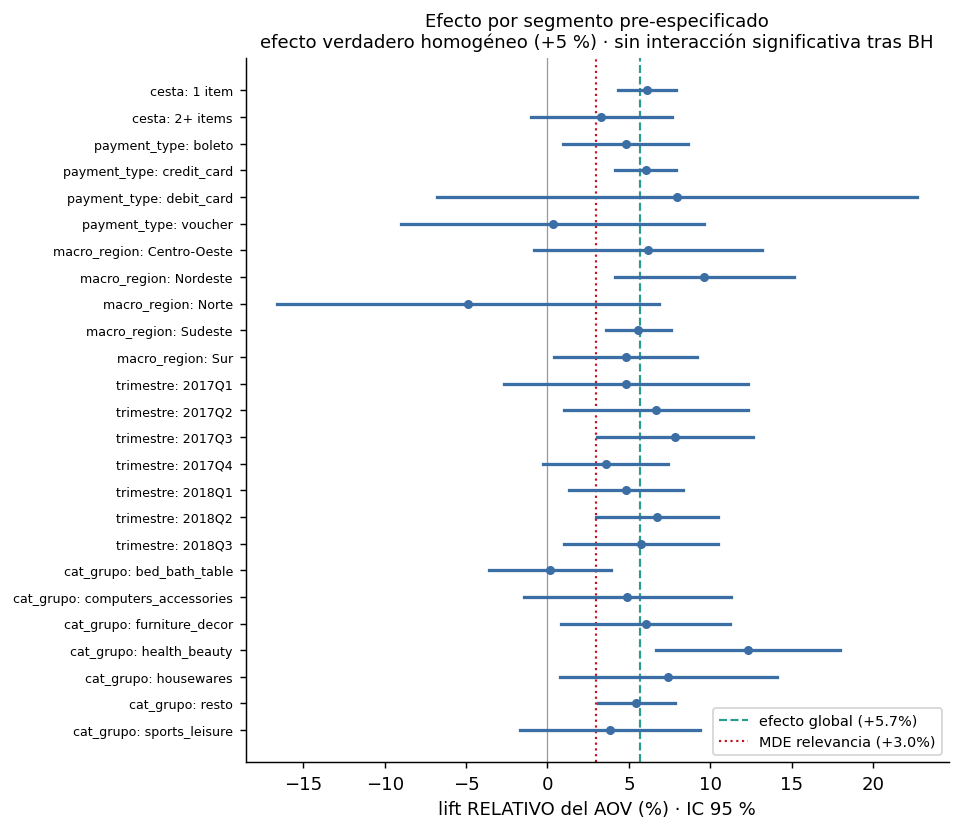

In [13]:
print("SEGMENTOS PRE-ESPECIFICADOS  —  test de interacción (log(AOV), Wald HC3, + Benjamini-Hochberg)")
for k, v in res5["4_segmentos"]["test_interaccion"].items():
    print(f"  {k:14}  p bruto = {v['p_bruto']:.3f}   p BH = {v['p_BH']:.3f}   "
          f"heterogéneo: {v['heterogeneidad_significativa_tras_BH']}")
print("\nP-HACKING  —  38 cortes exploratorios (esperados por azar ≈ 1,9)")
ph = res5["5_p_hacking"]
for esc in ["test_en_NIVEL_(mv_w)", "test_en_LOG_(efecto_relativo)"]:
    s = ph[esc]
    print(f"  {esc:32}  nominales = {s['nominales_p<0.05']['n']}  ·  tras BH = {s['tras_BH']['n']}  "
          f"·  tras Bonferroni = {s['tras_Bonferroni']}")
print("  -> En la escala equivocada (nivel) los artefactos mecánicos del efecto multiplicativo")
print("     sobreviven incluso a Bonferroni; en la escala correcta (log) no queda nada.")
display(Image("outputs/figures/f5_01_forest_segmentos.png"))

In [14]:
dec = res5["6_decision"]
print("=" * 60)
print(f"  DECISIÓN DE PRODUCTO:  {dec['decision']}")
print("=" * 60)
for j in dec["justificacion"]:
    print(f"  • {j}")
print("\n  Caveats:")
for cv in dec["caveats"]:
    print(f"  • {cv}")

  DECISIÓN DE PRODUCTO:  LANZAR
  • Efecto primario +5.67% (IC95 [3.99, 7.34]), log10(p) = -10.51 -> muy significativo.
  • IC 95 % completamente por encima del MDE de relevancia (+3.0%) -> relevante para negocio.
  • Ningún guardrail degradado (Fase 4, Benjamini-Hochberg).
  • Efecto homogéneo entre segmentos pre-especificados (sin interacción tras BH).
  • Estimación ajustada por covariables (ANCOVA): +5.193% con SE 11.23% menor.
  • Impacto estimado: +R$ 456,084/año de GMV de mercancía (IC [321,514, 590,655]).

  Caveats:
  • El efecto es sintético y declarado: esta 'decisión' valida el proceso, no un hallazgo real.
  • El estimador puntual (+5,7%) supera el ATE inyectado (+5%) por el desbalance basal del split (+1,2%, no significativo); el IC lo cubre.


---
## Fase 6 — Despliegue (Deployment)

- **Resumen ejecutivo (1 página, no técnico):** `docs/resumen_ejecutivo.md`
- **README del repositorio:** `README.md`
- **Borrador de post de LinkedIn:** `docs/linkedin_post.md`
- **Documentación por fase:** `docs/0X_*.md` · **auditorías:** `docs/auditoria_*.md`

### Qué demuestra este proyecto

1. **Diseño experimental completo** en un dominio de marketplace: hipótesis, métrica primaria única,
   guardrails, MDE de relevancia y regla de decisión — *antes* de mirar datos.
2. **Power analysis** a priori y **verificación empírica** (A/A sobre 2.000 particiones: falsos
   positivos al 5 %, p-valores uniformes).
3. **Verificación de supuestos** que cambia el test elegido (heterocedasticidad bajo H1 → Welch).
4. **Separación de significancia y relevancia** de negocio, con impacto en R$.
5. **Control de p-hacking**: segmentos pre-especificados, corrección por multiplicidad, y una
   demostración de cómo la escala equivocada del estimando fabrica hallazgos que ni Bonferroni
   elimina.
6. **Honestidad metodológica**: el efecto es sintético y declarado; el proyecto valida el *proceso*.